tempo_ensemble

timesfm_2_0_500m

GRAIN

Moirai_large

moirai_small

Kairos_23m

Kairos_10m

Moirai_base

Kairos_50m

auto_ets

tft

N-BEATS

PatchTST

tabpfn_ts

Moirai2

timesfm

deepar

chronos-2-synth

chronos_bolt_base

TimesFM-2.5

chronos_base

chronos_large

chronos_bolt_small

auto_arima

Chronos_small

seasonal_naive


 rank              model    model_type testdata_leakage  MASE  MASE_norm
    1     TEMPO-ensemble    fine-tuned              Yes 2.398      0.605
    2   TimesFM 2.0-500M    pretrained              Yes 2.538      0.640
    3              GRAIN           NaN              NaN 2.899      0.731
    4       Moirai-large     zero-shot               No 2.970      0.749
    5       Moirai-small     zero-shot               No 2.980      0.751
    6        xLSTM-Mixer deep-learning               No 2.984      0.752
    7         Kairos-23M     zero-shot               No 2.984      0.752
    8         Kairos-10M     zero-shot               No 2.985      0.753
    9        Moirai-base     zero-shot               No 3.010      0.759
   10         Kairos-50M     zero-shot               No 3.044      0.768
   11           Auto-ETS   statistical               No 3.080      0.777
   12                TFT deep-learning               No 3.090      0.779
   13         Auto-Theta   statistical             

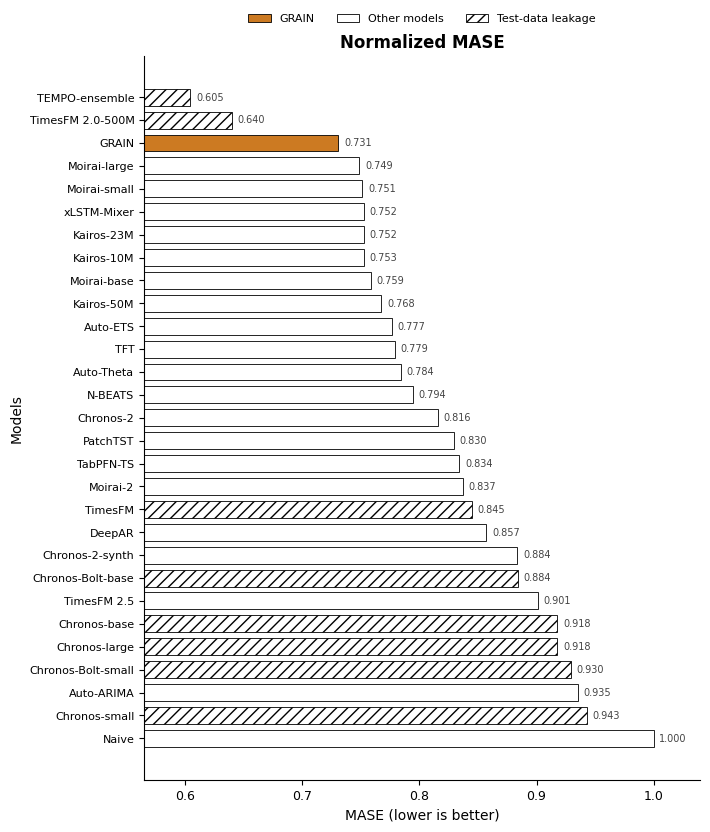

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# CSV model id -> paper display name (see the GIFT-Eval baselines paragraph)
DISPLAY_NAMES = {
    # ours
    "GRAIN": "GRAIN",
    # statistical
    "auto_arima": "Auto-ARIMA",
    "auto_ets": "Auto-ETS",
    "auto_theta": "Auto-Theta",
    #"seasonal_naive": "Seasonal Naive",
    # deep learning
    "N-BEATS": "N-BEATS",
    "PatchTST": "PatchTST",
    "tft": "TFT",
    "deepar": "DeepAR",
    "xLSTM-Mixer": "xLSTM-Mixer",
    # foundation models
    "timesfm": "TimesFM",
    "timesfm_2_0_500m": "TimesFM 2.0-500M",
    "TimesFM-2.5": "TimesFM 2.5",
    "chronos_base": "Chronos-base",
    "chronos_large": "Chronos-large",
    "Chronos_small": "Chronos-small",
    "chronos_bolt_base": "Chronos-Bolt-base",
    "chronos_bolt_small": "Chronos-Bolt-small",
    "chronos-2": "Chronos-2",
    "chronos-2-synth": "Chronos-2-synth",
    "Kairos_10m": "Kairos-10M",
    "Kairos_23m": "Kairos-23M",
    "Kairos_50m": "Kairos-50M",
    "moirai_small": "Moirai-small",
    "Moirai_base": "Moirai-base",
    "Moirai_large": "Moirai-large",
    "Moirai2": "Moirai-2",
    "tabpfn_ts": "TabPFN-TS",
    "tempo_ensemble": "TEMPO-ensemble",
    "naive": "Naive",
}

MODELS = list(DISPLAY_NAMES)

BASE, HL = "#FFFFFF", "#CC7A22"   # blue / orange — CVD-safe pair
HIGHLIGHT = "GRAIN"            # display name
FMT = "{:.3f}".format             # 3 decimals everywhere: tables and bar labels


def prepare(df, value_cols):
    """Filter to MODELS, rename to paper display names, re-rank by the first value col."""
    d = df[df["model"].isin(MODELS)].copy()

    missing = set(MODELS) - set(d["model"])
    if missing:
        print("missing from csv:", sorted(missing))

    d["model"] = d["model"].map(DISPLAY_NAMES)
    d = d.sort_values(value_cols[0]).reset_index(drop=True)
    d.insert(0, "rank", range(1, len(d) + 1))
    return d[["rank", "model", "model_type", "testdata_leakage", *value_cols]]


def plot_normalized(df, value_col, title, xlabel):
    """Horizontal bars of a normalized metric, best at top, HIGHLIGHT in orange."""
    d = df.sort_values(value_col, ascending=False).reset_index(drop=True)
    colors = [HL if m == HIGHLIGHT else BASE for m in d["model"]]

    fig, ax = plt.subplots(figsize=(7.2, 8.4))
    bars = ax.barh(d["model"], d[value_col], color=colors,
                   edgecolor="black", linewidth=0.6, height=0.74, zorder=3)
    for bar, leak in zip(bars, d["testdata_leakage"]):
        if leak == "Yes":
            bar.set_hatch("///")

    lo, hi = d[value_col].min(), d[value_col].max()
    span = hi - lo
    ax.set_xlim(lo - 0.10 * span, hi + 0.10 * span)   # zoomed baseline — values labelled below

    for bar, v in zip(bars, d[value_col]):
        ax.text(v + 0.012 * span, bar.get_y() + bar.get_height() / 2, FMT(v),
                va="center", ha="left", fontsize=7, color="#444444", zorder=4)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Models", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(False)                       # no vertical strips across the bars
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_zorder(5)       # keep the y axis above the bar ends

    ax.legend(
        handles=[
            Patch(facecolor=HL, edgecolor="black", lw=0.6, label=HIGHLIGHT),
            Patch(facecolor=BASE, edgecolor="black", lw=0.6, label="Other models"),
            Patch(facecolor="white", edgecolor="black", lw=0.6, hatch="///", label="Test-data leakage"),
        ],
        loc="lower center", bbox_to_anchor=(0.5, 1.03), ncol=3, frameon=False, fontsize=8,
    )
    fig.tight_layout()
    return fig, ax


# --- MASE ---
mase = pd.read_csv("results_yearly_mase_normalized.csv").drop(columns="rank")
mase = mase.rename(columns={"eval_metrics/MASE[0.5]": "MASE", "normalized": "MASE_norm"})
mase = prepare(mase, ["MASE", "MASE_norm"])

print(mase.to_string(index=False, float_format=FMT))

plot_normalized(mase, "MASE_norm", "Normalized MASE", "MASE (lower is better)")
plt.show()


 rank              model    model_type testdata_leakage   WQL  CRPS
    1   TimesFM 2.0-500M    pretrained              Yes 0.091 0.661
    2              GRAIN           NaN              NaN 0.103 0.754
    3       Moirai-large     zero-shot               No 0.104 0.758
    4        Moirai-base     zero-shot               No 0.105 0.766
    5       Moirai-small     zero-shot               No 0.105 0.766
    6         Kairos-23M     zero-shot               No 0.110 0.801
    7                TFT deep-learning               No 0.110 0.802
    8         Kairos-10M     zero-shot               No 0.110 0.802
    9           Auto-ETS   statistical               No 0.111 0.809
   10          Chronos-2    pretrained               No 0.112 0.813
   11        xLSTM-Mixer deep-learning               No 0.112 0.818
   12             DeepAR deep-learning               No 0.113 0.824
   13         Kairos-50M     zero-shot               No 0.114 0.831
   14         Auto-Theta   statistical          

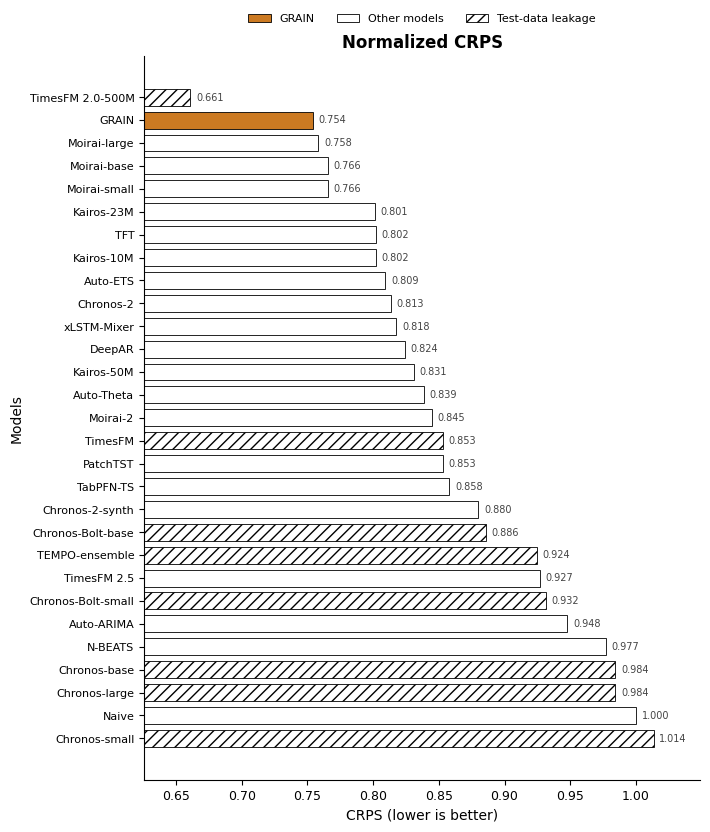

In [14]:
# --- Quantile: WQL (raw) and CRPS (normalized vs Seasonal Naive) ---
quant = pd.read_csv("results_yearly_quantile_normalized.csv").drop(columns="rank")
quant = quant.rename(columns={
    "eval_metrics/mean_weighted_sum_quantile_loss": "WQL",
    "normalized": "CRPS",
})
quant = prepare(quant, ["WQL", "CRPS"])

print(quant.to_string(index=False, float_format=FMT))

plot_normalized(quant, "CRPS", "Normalized CRPS", "CRPS (lower is better)")
plt.show()
